In [1]:
import os
os.environ["PYTHONWARNINGS"] = "ignore"

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import liana as li
import scanpy as sc
import numpy as np

from plotnine import theme, element_text, element_blank

In [4]:
sc.settings.set_figure_params(frameon=False)
sc.settings.verbosity = 2

In [5]:
# set working directory
project_dir = os.path.join(os.path.expanduser("~"), "BreastCancerG0arrest/")
working_dir = project_dir + "00_revisions/"
os.chdir(working_dir)

# figure directory
figure_dir = working_dir + "figures/"
# data directory
data_dir = working_dir + "data/"

In [6]:
# Read in
adata = sc.read(data_dir + "adata_full_harmony_integration.h5ad")

In [7]:
adata = adata[adata.obs["type"].isin(["ER", "PR", "HER", "TNBC"]), :].copy()

In [8]:
# Store the counts for later use 
adata.layers["counts"] = adata.X.copy()

In [9]:
# log1p normalize the data
sc.pp.filter_genes(adata, min_cells=50)
sc.pp.normalize_total(adata, target_sum=1e4)
adata.X = np.log1p(adata.X)

filtered out 1224 genes that are detected in less than 50 cells
normalizing counts per cell
    finished (0:00:01)


In [10]:
new_vals = adata.obs.loc[adata.obs["cycling_state_oren"].notna(), "cycling_state_oren"].astype(str)
adata.obs["cell_type"] = adata.obs["celltype"].cat.add_categories(new_vals.unique())
adata.obs.loc[adata.obs["cycling_state_oren"].notna(), "cell_type"] = new_vals
adata.obs["cell_type"] = adata.obs["cell_type"].cat.remove_unused_categories()
adata.obs["cell_type"].cat.categories

Index(['B cell', 'CD4+ T cell', 'Cancer-associated fibroblast', 'Endothelial',
       'Fibroblast', 'Macrophage', 'Mast cell', 'NK/CD8+ T cell', 'Pericyte',
       'Plasma cell', 'Regulatory T cell', 'Tumour-associated macrophage',
       'cDC', 'pDC', 'Slow-cycling', 'G0-arrested', 'Fast-cycling'],
      dtype='object')

In [11]:
# assign cell types based on cycling_state
adata.obs["cell_type"] = adata.obs["cell_type"].cat.rename_categories(
    {
        "B cell": "B_cell",
        "Cancer-associated fibroblast": "CAF",
        "CD4+ T cell": "CD4_T_cell",
        "NK/CD8+ T cell": "CD8_T_cell",
        "G0-arrested": "G0_arrested",
        "Fast-cycling": "Fast_cycling",
        "Plasma cell": "Plasma_cell",
        "Regulatory T cell": "T_reg",
        "Slow-cycling": "Slow_cycling",
        "Tumour-associated macrophage": "TAM",
        "Mast cell": "Mast"
    }
)

In [12]:
new_order = [
    "Fast_cycling",
    "Slow_cycling",
    "G0_arrested",
    "B_cell",
    "CAF",
    "CD4_T_cell",
    "CD8_T_cell",
    "Endothelial",
    "Fibroblast",
    "Macrophage",
    "Mast",
    "Pericyte",
    "Plasma_cell",
    "TAM",
    "T_reg",
    "cDC",
    "pDC",
]

adata.obs["cell_type"] = adata.obs["cell_type"].cat.reorder_categories(new_order, ordered=True)

In [13]:
li.mt.rank_aggregate(
    adata,
    groupby="cell_type",
    resource_name="consensus",
    aggregate_method="rra",
    expr_prop=0.1,
    use_raw=False,
    de_method="wilcoxon",
    return_all_lrs=False,
    verbose=True,
    n_jobs=32,
)

Using resource `consensus`.
Using `.X`!
0.16 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 107604 samples and 1526 features
Assuming that counts were `natural` log-normalized!
Running CellPhoneDB


100%|██████████| 1000/1000 [00:15<00:00, 64.17it/s]


Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR


In [14]:
sources = [
    "B_cell", "CD4_T_cell", "CAF", "Endothelial", "Fibroblast", "Macrophage",
    "Mast", "CD8_T_cell", "Pericyte", "Plasma_cell", "T_reg", "TAM", "cDC", "pDC"
]
targets = ["G0_arrested", "Fast_cycling", "Slow_cycling"]

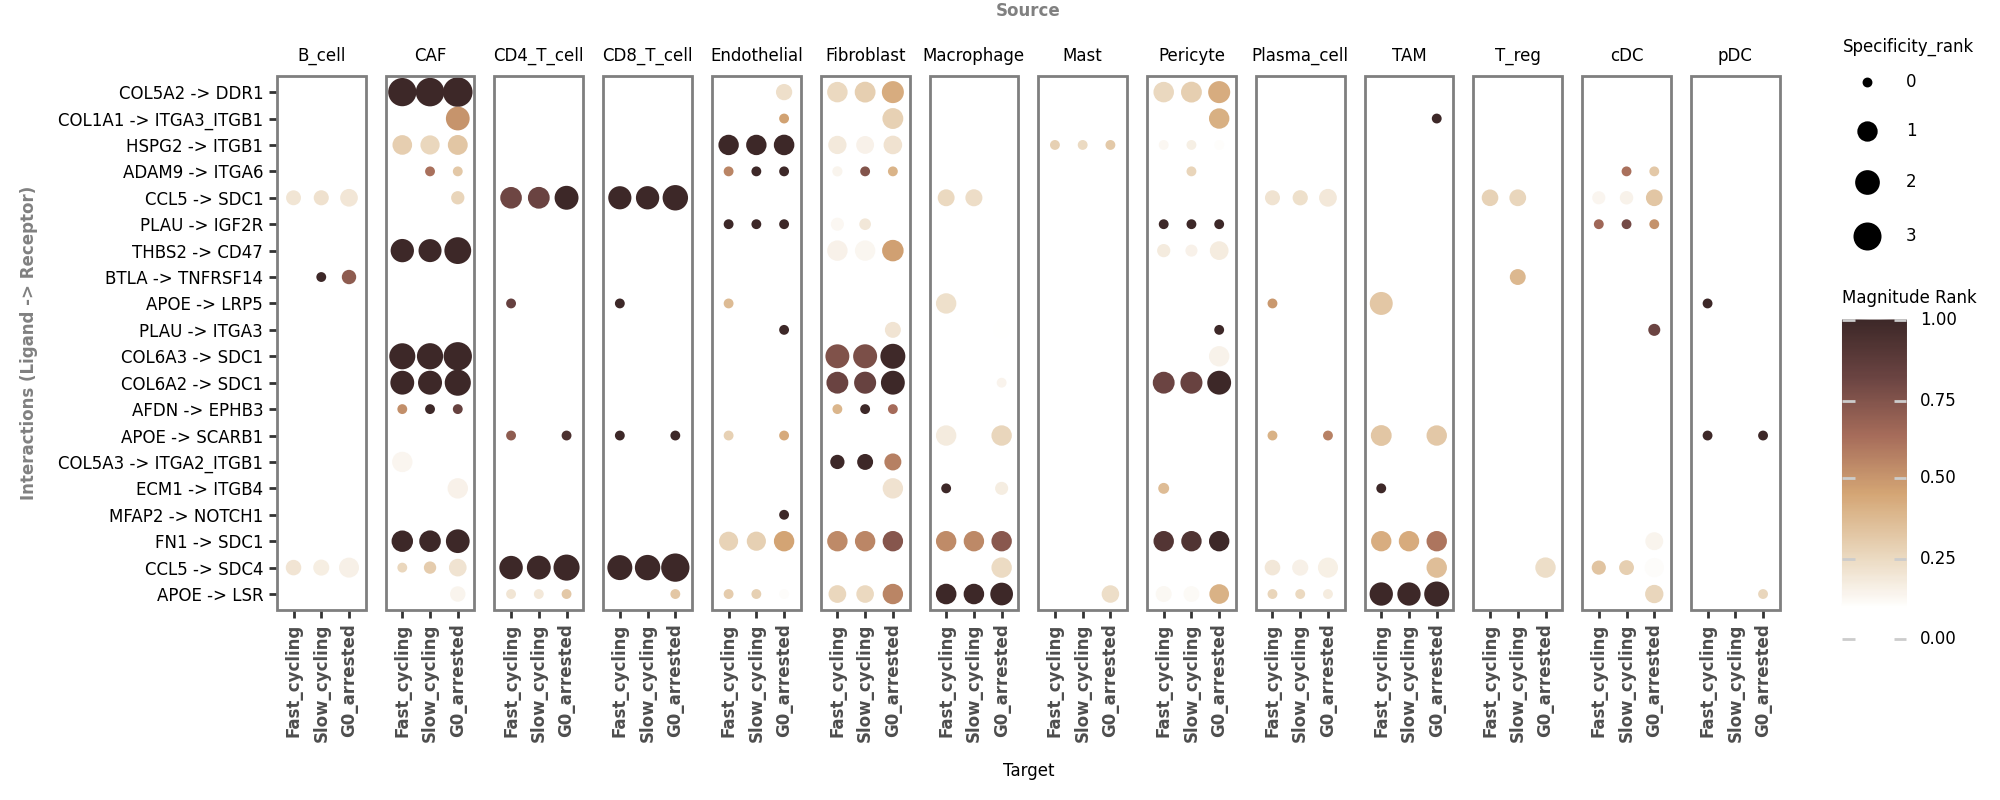

In [15]:
from plotnine import scale_x_discrete, scale_color_gradientn

figure = (
    li.pl.dotplot(
        adata=adata,
        colour="magnitude_rank",
        size="specificity_rank",
        inverse_colour=True,
        inverse_size=True,
        source_labels=sources,
        target_labels=targets,
        filter_fun=lambda x: x["specificity_rank"] <= 0.25
        and x["magnitude_rank"] > 0.5,
        orderby="magnitude_rank",
        orderby_ascending=True,
        top_n=20,
        figure_size=(10, 4),
        size_range=(1, 5),
        cmap="turbo",
    )
    + theme(text=element_text(size=6), panel_grid=element_blank(), strip_background=element_blank())
    + scale_x_discrete(limits=["Fast_cycling", "Slow_cycling", "G0_arrested"])
    + scale_color_gradientn(
        colors=[
            "#ffffff",
            "#ffffff",
            "#ffffff",  # off-white cream
            "#e8d4b8",  # beige
            "#d4a574",  # tan
            "#a66c5a",  # terracotta
            "#6b4442",  # muted maroon
            "#3d2828",
        ],  # dark brown
        values=[0, 0.1, 0.1, 0.28, 0.46, 0.64, 0.82, 1],
        limits=(0, 1),
        name="Magnitude Rank",
    )
)

figure.save(figure_dir + "liana_dotplot_filtered_interactions.pdf")
figure

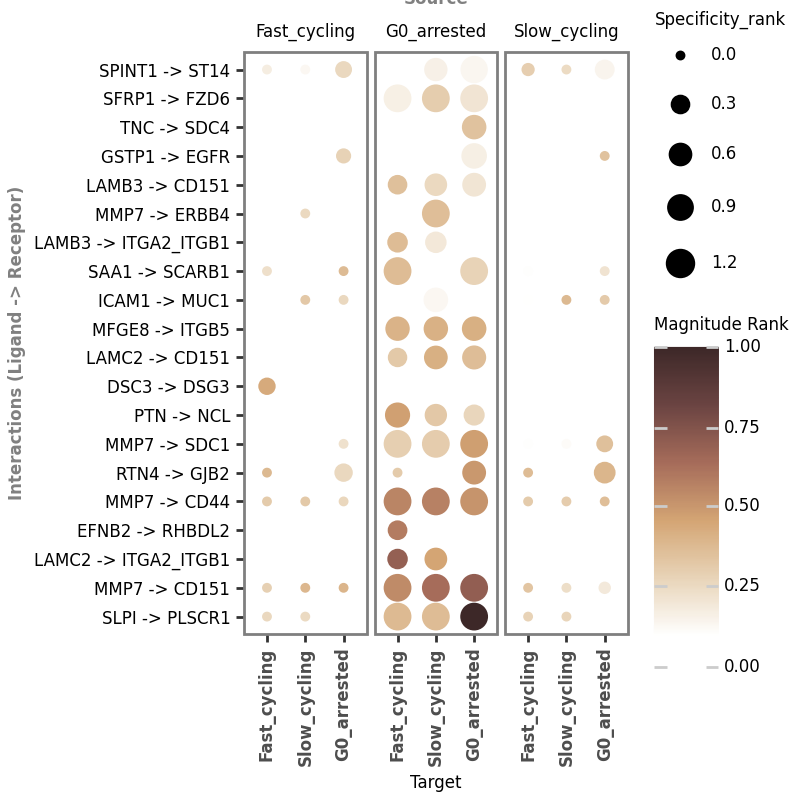

In [16]:
figure = (li.pl.dotplot(
    adata=adata,
    colour="magnitude_rank",
    size="specificity_rank",
    inverse_colour=True,
    inverse_size=True,
    source_labels=targets,
    target_labels=targets,
    filter_fun=lambda x: x["specificity_rank"] <= 0.25 and x["magnitude_rank"] > 0.25,
    orderby="magnitude_rank",
    orderby_ascending=True,
    top_n=20,
    figure_size=(4, 4),
    size_range=(1, 5),
    cmap="turbo",
) + theme(text=element_text(size=6), panel_grid=element_blank(), strip_background=element_blank())
    + scale_x_discrete(limits=["Fast_cycling", "Slow_cycling", "G0_arrested"])
    + scale_color_gradientn(
        colors=[
            "#ffffff",
            "#ffffff",
            "#ffffff",  # off-white cream
            "#e8d4b8",  # beige
            "#d4a574",  # tan
            "#a66c5a",  # terracotta
            "#6b4442",  # muted maroon
            "#3d2828",
        ],  # dark brown
        values=[0, 0.1, 0.1, 0.28, 0.46, 0.64, 0.82, 1],
        limits=(0, 1),
        name="Magnitude Rank",
    )
)

figure.save(figure_dir + "liana_dotplot_filtered_interactions_targets.pdf")
figure